# 🎧 Eletrônica Analógica

`Hardware` · **8º semestre · Engenharia da Computação** · `Python 3`

> **Diodos, BJT, MOSFET, amplificadores e amp-op.**

Dispositivos semicondutores e amplificadores: diodos e retificadores, polarização de transistores, ganho de amp-ops e resposta em frequência.


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF gerado abaixo).

### 🟢 DIODOS & RETIFICADORES

**Ideia:** Entender condução unidirecional, retificação e modelos práticos de diodos.

- Diodo ideal: ON ≈ curto; OFF ≈ circuito aberto
- Silício: V_D ≈ 0,7 V em condução
- Equação: I_D = I_S(e^V_D/(nV_T)-1)
- Meia onda: usa 1 diodo; conduz em um semiciclo
- Onda completa: ponte usa 4 diodos; |v(t)| na saída
- Filtro C: reduz ripple após a retificação
- Zener: opera em ruptura reversa para regulação
- Proteção: sempre limite corrente com resistência

> 💡 **Dica:** Antes de calcular, descubra se cada diodo está ON ou OFF. Depois substitua pelo modelo equivalente e resolva o circuito.

### 🟢 TRANSISTOR BJT & POLARIZAÇÃO

**Ideia:** Usar corrente de base para controlar corrente de coletor e definir o ponto de operação.

- Relação: I_E = I_C + I_B
- Ganho: β = I_C/I_B
- Ativa: V_BE ≈ 0,7 V e I_C ≈ βI_B
- Corte: I_B≈0 ⇒ I_C≈0
- Saturação: V_CE ≈ 0,2 V (modelo prático)
- Polarização: fixa o ponto Q para amplificação linear
- Emissor comum: fornece ganho de tensão e inversão
- Pequeno sinal: g_m ≈ I_C/V_T

> 💡 **Dica:** Para amplificar sem distorção, mantenha o BJT na região ativa. Corte e saturação são típicos de operação como chave.

### 🟢 MOSFET & AMPLIFICADORES

**Ideia:** Controlar corrente pelo campo elétrico no gate e analisar estágios de ganho.

- Gate: corrente ideal ≈ 0 ⇒ alta impedância de entrada
- Corte: V_GS < V_TH ⇒ I_D≈0
- Triodo: V_DS < V_GS-V_TH
- Saturação: V_DS ≥ V_GS-V_TH
- Modelo: I_D ≈ k(V_GS-V_TH)²/2
- Fonte comum: ganho de tensão com inversão
- Seguidor de fonte: A_v≈1 e baixa R_out
- Pequeno sinal: g_m = ∂I_D/∂V_GS

> 💡 **Dica:** Primeiro identifique a região de operação do MOSFET. As equações mudam entre corte, triodo e saturação.

### 🟢 AMPLIFICADOR OPERACIONAL

**Ideia:** Usar realimentação para construir amplificadores, somadores, integradores e filtros ativos.

- Ideal: A→∞, R_in→∞, R_out→0
- Realimentação negativa: v_+ ≈ v_- e i_+≈i_-≈0
- Inversor: A_v = -R_f/R_in
- Não inversor: A_v = 1 + R_f/R_1
- Seguidor: A_v ≈ 1
- Somador: v_o = -R_fΣ(v_i/R_i)
- Integrador: v_o = -(1/RC)∫v_idt
- Saturação: saída não pode ultrapassar os trilhos de alimentação

> 💡 **Dica:** O “curto virtual” v+≈v− só vale com realimentação negativa e operação linear. Se a saída saturar, essa hipótese deixa de valer.


## ⚙️ Gerador do Cheat Sheet (PDF)

O script original gera um **PDF estilo OneNote** com `reportlab`. Para rodar em qualquer sistema operacional, as fontes são resolvidas automaticamente (usa a **DejaVu embarcada no matplotlib** com fallback para os caminhos clássicos de Windows/Linux/macOS) e o arquivo de saída é gerado na pasta atual.


In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path
from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Eletronica_Analogica.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily('DVCond', normal='DVCond', bold='DVCond-Bold', italic='DVCond-Oblique', boldItalic='DVCond-Bold')

BG=HexColor('#F6F8FB'); GRID=HexColor('#E6EBF3'); INK=HexColor('#1C2B4A'); MUTED=HexColor('#5A6B8C'); WHITE=HexColor('#FFFFFF'); LINE=HexColor('#E7ECF4'); AXIS=HexColor('#D7DEEA')
TEAL,TEAL_T=HexColor('#147D82'),HexColor('#E3F2F1'); AMBER,AMBER_T=HexColor('#C97A1A'),HexColor('#FBEDDD'); BERRY,BERRY_T=HexColor('#A83E63'),HexColor('#F6E4EB'); GREEN,GREEN_T=HexColor('#2F7A4F'),HexColor('#E2F0E7')

CARDS=[
 {'title':'DIODOS &amp;<br/>RETIFICADORES','color':TEAL,'tint':TEAL_T,'kind':'diodo','idea':'Entender condução unidirecional, retificação e modelos práticos de diodos.','formulas':[
  '<b>Diodo ideal:</b> ON ≈ curto; OFF ≈ circuito aberto',
  '<b>Silício:</b> V<sub>D</sub> ≈ 0,7 V em condução',
  '<b>Equação:</b> I<sub>D</sub> = I<sub>S</sub>(e<super>V<sub>D</sub>/(nV<sub>T</sub>)</super>-1)',
  '<b>Meia onda:</b> usa 1 diodo; conduz em um semiciclo',
  '<b>Onda completa:</b> ponte usa 4 diodos; |v(t)| na saída',
  '<b>Filtro C:</b> reduz ripple após a retificação',
  '<b>Zener:</b> opera em ruptura reversa para regulação',
  '<b>Proteção:</b> sempre limite corrente com resistência',
 ],'tip':'Antes de calcular, descubra se cada diodo está ON ou OFF. Depois substitua pelo modelo equivalente e resolva o circuito.'},
 {'title':'TRANSISTOR BJT<br/>&amp; POLARIZAÇÃO','color':AMBER,'tint':AMBER_T,'kind':'bjt','idea':'Usar corrente de base para controlar corrente de coletor e definir o ponto de operação.','formulas':[
  '<b>Relação:</b> I<sub>E</sub> = I<sub>C</sub> + I<sub>B</sub>',
  '<b>Ganho:</b> β = I<sub>C</sub>/I<sub>B</sub>',
  '<b>Ativa:</b> V<sub>BE</sub> ≈ 0,7 V e I<sub>C</sub> ≈ βI<sub>B</sub>',
  '<b>Corte:</b> I<sub>B</sub>≈0 ⇒ I<sub>C</sub>≈0',
  '<b>Saturação:</b> V<sub>CE</sub> ≈ 0,2 V (modelo prático)',
  '<b>Polarização:</b> fixa o ponto Q para amplificação linear',
  '<b>Emissor comum:</b> fornece ganho de tensão e inversão',
  '<b>Pequeno sinal:</b> g<sub>m</sub> ≈ I<sub>C</sub>/V<sub>T</sub>',
 ],'tip':'Para amplificar sem distorção, mantenha o BJT na região ativa. Corte e saturação são típicos de operação como chave.'},
 {'title':'MOSFET &amp;<br/>AMPLIFICADORES','color':BERRY,'tint':BERRY_T,'kind':'mosfet','idea':'Controlar corrente pelo campo elétrico no gate e analisar estágios de ganho.','formulas':[
  '<b>Gate:</b> corrente ideal ≈ 0 ⇒ alta impedância de entrada',
  '<b>Corte:</b> V<sub>GS</sub> &lt; V<sub>TH</sub> ⇒ I<sub>D</sub>≈0',
  '<b>Triodo:</b> V<sub>DS</sub> &lt; V<sub>GS</sub>-V<sub>TH</sub>',
  '<b>Saturação:</b> V<sub>DS</sub> ≥ V<sub>GS</sub>-V<sub>TH</sub>',
  '<b>Modelo:</b> I<sub>D</sub> ≈ k(V<sub>GS</sub>-V<sub>TH</sub>)²/2',
  '<b>Fonte comum:</b> ganho de tensão com inversão',
  '<b>Seguidor de fonte:</b> A<sub>v</sub>≈1 e baixa R<sub>out</sub>',
  '<b>Pequeno sinal:</b> g<sub>m</sub> = ∂I<sub>D</sub>/∂V<sub>GS</sub>',
 ],'tip':'Primeiro identifique a região de operação do MOSFET. As equações mudam entre corte, triodo e saturação.'},
 {'title':'AMPLIFICADOR<br/>OPERACIONAL','color':GREEN,'tint':GREEN_T,'kind':'opamp','idea':'Usar realimentação para construir amplificadores, somadores, integradores e filtros ativos.','formulas':[
  '<b>Ideal:</b> A→∞, R<sub>in</sub>→∞, R<sub>out</sub>→0',
  '<b>Realimentação negativa:</b> v<sub>+</sub> ≈ v<sub>-</sub> e i<sub>+</sub>≈i<sub>-</sub>≈0',
  '<b>Inversor:</b> A<sub>v</sub> = -R<sub>f</sub>/R<sub>in</sub>',
  '<b>Não inversor:</b> A<sub>v</sub> = 1 + R<sub>f</sub>/R<sub>1</sub>',
  '<b>Seguidor:</b> A<sub>v</sub> ≈ 1',
  '<b>Somador:</b> v<sub>o</sub> = -R<sub>f</sub>Σ(v<sub>i</sub>/R<sub>i</sub>)',
  '<b>Integrador:</b> v<sub>o</sub> = -(1/RC)∫v<sub>i</sub>dt',
  '<b>Saturação:</b> saída não pode ultrapassar os trilhos de alimentação',
 ],'tip':'O “curto virtual” v+≈v− só vale com realimentação negativa e operação linear. Se a saída saturar, essa hipótese deixa de valer.'}
]

CARD_TOP=PAGE_H-16; CARD_BOTTOM=16; CARD_H=CARD_TOP-CARD_BOTTOM; GAP=14; CARD_W=(PAGE_W-2*MARGIN-3*GAP)/4
STYLE_TITLE=ParagraphStyle('card_title',fontName='DVCond-Bold',fontSize=17.2,leading=18.6,textColor=WHITE,alignment=1,spaceAfter=0)
STYLE_IDEA=ParagraphStyle('idea',fontName='DVCond-Oblique',fontSize=12.6,leading=15.6,textColor=MUTED)
STYLE_TIP=ParagraphStyle('tip',fontName='DVCond',fontSize=11.7,leading=14.7,textColor=INK)

def arrow(c,x1,y1,x2,y2,color,width=1.2,head=5):
 c.setStrokeColor(color); c.setFillColor(color); c.setLineWidth(width); c.line(x1,y1,x2,y2); ang=math.atan2(y2-y1,x2-x1)
 for d in (2.55,-2.55): c.line(x2,y2,x2+head*math.cos(ang+d),y2+head*math.sin(ang+d))

def axis(c,ox,oy,dw,dh):
 ay=oy+dh*0.12; c.setStrokeColor(AXIS); c.setLineWidth(0.8); c.line(ox,ay,ox+dw,ay); c.line(ox+dw*0.03,oy,ox+dw*0.03,oy+dh); return ay

def diagram_diodo(c,ox,oy,dw,dh,color):
 y=oy+dh*0.58; x0=ox+dw*0.12; x1=ox+dw*0.88
 c.setStrokeColor(INK); c.setLineWidth(1.1); c.line(x0,y,x0+35,y); c.line(x1-35,y,x1,y)
 c.setStrokeColor(color); c.setLineWidth(1.5)
 p=c.beginPath(); p.moveTo(x0+35,y-15); p.lineTo(x0+35,y+15); p.lineTo(x0+62,y); p.close(); c.drawPath(p,stroke=1,fill=0)
 c.line(x0+66,y-16,x0+66,y+16); c.line(x0+66,y,x1-35,y)
 arrow(c,x0+4,y+24,x1-4,y+24,color,1.0,4)
 c.setFillColor(color); c.setFont('DVCond-Bold',9.8); c.drawCentredString((x0+x1)/2,y+31,'I_D')
 c.setFillColor(INK); c.setFont('DVCond-Bold',10.2); c.drawCentredString((x0+x1)/2,oy+dh*0.15,'ON ≈ 0,7 V   •   OFF ≈ aberto')

def diagram_bjt(c,ox,oy,dw,dh,color):
 cx=ox+dw*0.52; cy=oy+dh*0.52
 c.setStrokeColor(color); c.setLineWidth(1.4)
 c.line(cx-25,cy,cx,cy); c.line(cx,cy-22,cx,cy+22); c.line(cx,cy+12,cx+28,cy+30); c.line(cx,cy-12,cx+28,cy-30)
 arrow(c,cx+10,cy-18,cx+24,cy-28,color,1.0,4)
 c.setFillColor(INK); c.setFont('DVCond-Bold',9.5); c.drawString(cx-38,cy-3,'B'); c.drawString(cx+31,cy+27,'C'); c.drawString(cx+31,cy-34,'E')
 c.setFillColor(color); c.setFont('DVCond-Bold',10.2); c.drawCentredString(cx,oy+dh*0.15,'I_C ≈ β·I_B   •   V_BE ≈ 0,7 V')

def diagram_mosfet(c,ox,oy,dw,dh,color):
 cx=ox+dw*0.52; cy=oy+dh*0.52
 c.setStrokeColor(color); c.setLineWidth(1.4)
 c.line(cx,cy-23,cx,cy+23); c.line(cx+8,cy-18,cx+8,cy+18); c.line(cx+8,cy+15,cx+30,cy+30); c.line(cx+8,cy-15,cx+30,cy-30)
 c.line(cx-35,cy,cx-8,cy); c.setStrokeColor(INK); c.line(cx-8,cy-18,cx-8,cy+18)
 c.setFillColor(INK); c.setFont('DVCond-Bold',9.5); c.drawString(cx-44,cy-3,'G'); c.drawString(cx+33,cy+27,'D'); c.drawString(cx+33,cy-34,'S')
 c.setFillColor(color); c.setFont('DVCond-Bold',10.2); c.drawCentredString(cx,oy+dh*0.15,'V_GS controla I_D   •   I_G ≈ 0')

def diagram_opamp(c,ox,oy,dw,dh,color):
 cx=ox+dw*0.50; cy=oy+dh*0.54
 c.setStrokeColor(color); c.setLineWidth(1.5)
 p=c.beginPath(); p.moveTo(cx-38,cy-28); p.lineTo(cx-38,cy+28); p.lineTo(cx+28,cy); p.close(); c.drawPath(p,stroke=1,fill=0)
 c.setFillColor(INK); c.setFont('DVCond-Bold',11); c.drawString(cx-31,cy+12,'−'); c.drawString(cx-31,cy-18,'+'); c.drawString(cx+2,cy-4,'A')
 c.setStrokeColor(INK); c.line(cx-55,cy+15,cx-38,cy+15); c.line(cx-55,cy-15,cx-38,cy-15); c.line(cx+28,cy,cx+52,cy)
 c.setFillColor(color); c.setFont('DVCond-Bold',10.2); c.drawCentredString(cx,oy+dh*0.14,'v+ ≈ v−   •   i+ ≈ i− ≈ 0')

DIAGRAMS={'diodo':diagram_diodo,'bjt':diagram_bjt,'mosfet':diagram_mosfet,'opamp':diagram_opamp}

def draw_card(c,card,cx):
 color,tint=card['color'],card['tint']; c.setFillColor(WHITE); c.setStrokeColor(color); c.setLineWidth(1.5); c.roundRect(cx,CARD_BOTTOM,CARD_W,CARD_H,10,fill=1,stroke=1)
 header_h=58; header_y=CARD_TOP-7-header_h; c.setFillColor(color); c.roundRect(cx+5,header_y,CARD_W-10,header_h,6,fill=1,stroke=0)
 title=Paragraph(card['title'],STYLE_TITLE); _,th=title.wrapOn(c,CARD_W-22,header_h-6); title.drawOn(c,cx+11,header_y+(header_h-th)/2)
 cursor=header_y-11; diagram_h=76; diagram_y=cursor-diagram_h; DIAGRAMS[card['kind']](c,cx+11,diagram_y,CARD_W-22,diagram_h,color); cursor=diagram_y-10
 idea=Paragraph(card['idea'],STYLE_IDEA); _,ih=idea.wrapOn(c,CARD_W-22,70); idea.drawOn(c,cx+11,cursor-ih); cursor-=ih+9
 c.setStrokeColor(LINE); c.setLineWidth(0.8); c.line(cx+11,cursor,cx+CARD_W-11,cursor); cursor-=10
 tip_y=CARD_BOTTOM+8; tip=Paragraph('<b>Dica:</b> '+card['tip'],STYLE_TIP); _,tth=tip.wrapOn(c,CARD_W-34,130); tip_h=max(72,tth+22); tip_top=tip_y+tip_h
 formula_html='<br/>'.join('• '+item for item in card['formulas']); available_h=cursor-tip_top-10; fs=11.15; leading=14.15
 while True:
  st=ParagraphStyle('formula_'+card['kind'],fontName='DVCond',fontSize=fs,leading=leading,textColor=INK); formulas=Paragraph(formula_html,st); _,fh=formulas.wrapOn(c,CARD_W-22,470)
  if fh<=available_h or fs<=10.2: break
  fs-=0.1; leading-=0.1
 formulas.drawOn(c,cx+11,cursor-fh)
 c.setFillColor(tint); c.roundRect(cx+7,tip_y,CARD_W-14,tip_h,6,fill=1,stroke=0); tip.drawOn(c,cx+17,tip_y+(tip_h-tth)/2)

c=canvas.Canvas(str(OUT),pagesize=landscape(A4)); c.setTitle('Eletrônica Analógica - Cheat Sheet OneNote'); c.setAuthor('OpenAI')
c.setFillColor(BG); c.rect(0,0,PAGE_W,PAGE_H,fill=1,stroke=0); c.setStrokeColor(GRID); c.setLineWidth(0.35)
step=16; x=0
while x<PAGE_W: c.line(x,0,x,PAGE_H); x+=step
y=0
while y<PAGE_H: c.line(0,y,PAGE_W,y); y+=step
x=MARGIN
for card in CARDS: draw_card(c,card,x); x+=CARD_W+GAP
c.save(); print(f'PDF gerado em {OUT}')


PDF gerado em Eletronica_Analogica.pdf


## 🖼️ Resultado visual

As páginas do PDF gerado são renderizadas abaixo (código de pré-visualização). Este é o **cheat sheet** da matéria.


Páginas: 1


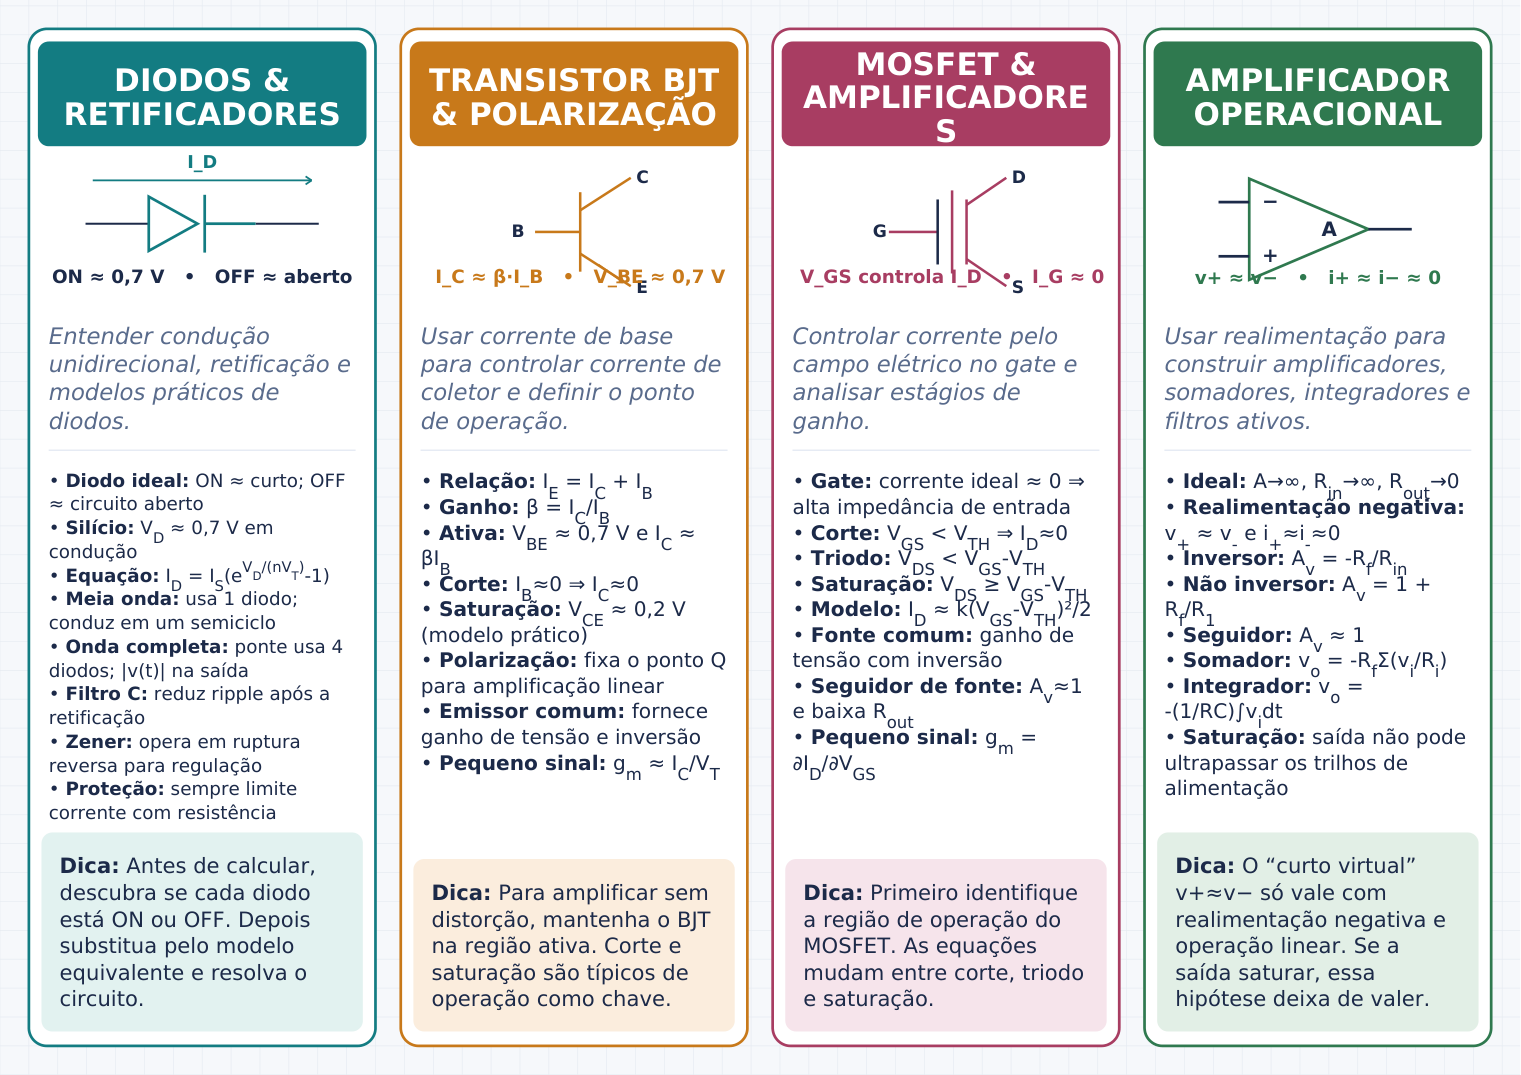

In [2]:
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Eletronica_Analogica.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


1) DIODO: retificacao de meia onda (Vp = 12 V)
   valor medio = 3.82 V | valor eficaz (meia onda) = 6.00 V


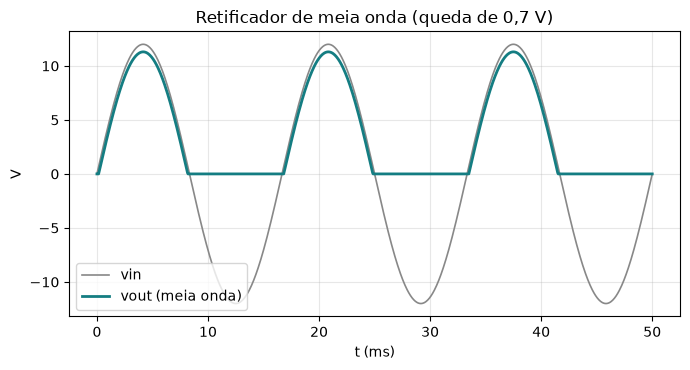


2) POLARIZACAO BJT: Vcc=12 V, Rb=470k, Rc=1k, beta=150
   Ib = 24.0 uA | Ic = 3.6 mA | Vce = 8.39 V (ATIVO)

3) AMPLIFICADOR INVERSOR: Rf = 10k, Rin = 1k
   Av = -10.0 (ganho de tensao)

   NAO INVERSOR: Rf = 9k, R1 = 1k
   Av = 10.0

4) SOMADOR: vo = -Rf*(v1/R1 + v2/R2)
   vo = -4.00 V

5) FILTRO RC passa-baixa: resposta em frequencia


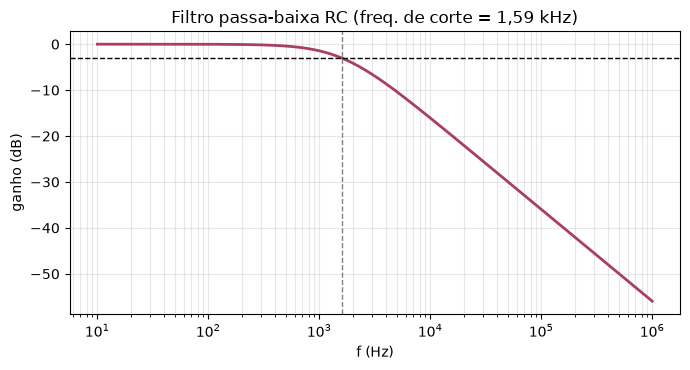


OK - semicondutores e amplificadores analisados.


In [3]:

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("1) DIODO: retificacao de meia onda (Vp = 12 V)")
Vp, R = 12.0, 1000.0
Vdc = Vp/np.pi
print(f"   valor medio = {Vdc:.2f} V | valor eficaz (meia onda) = {Vp/2:.2f} V")

t = np.linspace(0, 0.05, 1000)
vin = Vp*np.sin(2*np.pi*60*t)
vout = np.maximum(vin - 0.7, 0)   # queda de 0.7 V no silicio
plt.figure(figsize=(7, 3.8))
plt.plot(t*1e3, vin, color="#888", lw=1.2, label="vin")
plt.plot(t*1e3, vout, color="#147D82", lw=2, label="vout (meia onda)")
plt.title("Retificador de meia onda (queda de 0,7 V)"); plt.xlabel("t (ms)")
plt.ylabel("V"); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

print("\n2) POLARIZACAO BJT: Vcc=12 V, Rb=470k, Rc=1k, beta=150")
Vcc, Rb, Rc, beta = 12.0, 470e3, 1e3, 150
Ib = (Vcc - 0.7)/Rb
Ic = beta*Ib
Vce = Vcc - Ic*Rc
print(f"   Ib = {Ib*1e6:.1f} uA | Ic = {Ic*1e3:.1f} mA | Vce = {Vce:.2f} V "
      f"({'ATIVO' if 0.2 < Vce < Vcc else 'SATURADO/CORTE'})")

print("\n3) AMPLIFICADOR INVERSOR: Rf = 10k, Rin = 1k")
Rf, Rin = 10e3, 1e3
Av = -Rf/Rin
print(f"   Av = {Av} (ganho de tensao)")
print("\n   NAO INVERSOR: Rf = 9k, R1 = 1k")
Av2 = 1 + 9e3/1e3
print(f"   Av = {Av2}")

print("\n4) SOMADOR: vo = -Rf*(v1/R1 + v2/R2)")
v1, v2 = 1.0, 2.0
vo = -10e3*(v1/5e3 + v2/10e3)
print(f"   vo = {vo:.2f} V")

print("\n5) FILTRO RC passa-baixa: resposta em frequencia")
fc = 1/(2*np.pi*1e3*100e-9)
f = np.logspace(1, 6, 400)
H = 1/np.sqrt(1 + (f/fc)**2)
plt.figure(figsize=(7, 3.8))
plt.semilogx(f, 20*np.log10(H), color="#A83E63", lw=2)
plt.axhline(-3, color="k", ls="--", lw=1); plt.axvline(fc, color="gray", ls="--", lw=1)
plt.title("Filtro passa-baixa RC (freq. de corte = 1,59 kHz)")
plt.xlabel("f (Hz)"); plt.ylabel("ganho (dB)"); plt.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()
print("\nOK - semicondutores e amplificadores analisados.")


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
